In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from kneed import KneeLocator 

In [6]:
MONOPOLY_XLSX ='Base_clientes_Monopoly.xlsx'
MONOPOLY_CSV ='Base_clientes_Monopoly_otro.csv'

try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

df = pd.read_excel(MONOPOLY_XLSX)
df.head(10)

,Id,Subsegmento,Sexo,Region,Edad,Renta,Antiguedad,Internauta,Adicional,Dualidad,...,ColMx_T01,PagoNac_T01,PagoInt_T01,EeccNac_T01,EeccInt_T01,UsoL1_T01,UsoL2_T01,UsoLI_T01,IndRev_T01,target
0,1,160,M,13.0,43,NaN,130,1,1,0,...,0.0,33000,0.0,1099866.0,0.0,1099866.0,15080,0.0,R,0
1,2,160,H,13.0,46,143640.0,69,1,0,0,...,0.0,300000,0.0,214592.0,0.0,214592.0,83596,0.0,R,0
2,3,170,H,13.0,45,929106.0,24,1,1,0,...,0.0,216676,0.0,0.0,0.0,7400.0,0,0.0,T,0
3,4,151,H,13.0,46,172447.0,134,0,1,0,...,0.0,60000,0.0,272762.0,0.0,272762.0,10591,0.0,R,0
4,5,170,H,13.0,46,805250.0,116,0,1,1,...,0.0,272925,0.0,249562.0,0.0,75339.0,377782,0.0,R,0
5,6,170,H,13.0,47,707664.0,67,1,1,0,...,0.0,35800,0.0,35800.0,0.0,0.0,51197,0.0,R,0
6,7,811,H,13.0,48,1022833.0,21,1,0,1,...,0.0,9391,0.0,8818.0,0.0,8818.0,0,0.0,T,0
7,8,170,H,13.0,46,NaN,69,0,1,1,...,0.0,6000,0.0,283520.0,0.0,283520.0,0,0.0,R,0
8,9,170,H,13.0,49,1171066.0,33,0,0,0,...,0.0,60000,0.0,507629.0,0.0,507629.0,0,0.0,R,1
9,10,170,M,13.0,44,964387.0,23,1,1,0,...,0.0,92583,0.0,65487.0,0.0,65487.0,12084,0.0,R,0


In [7]:
df_nor = df.copy()

In [8]:
df_monopoly = (df_nor[['Region', 'Renta', 'Edad','Sexo', 'Adicional','Consumo', 'Cuentas', 'Hipotecario', 'Monoproducto' , 'TC', 'Dualidad']])
df_monopoly

,Region,Renta,Edad,Sexo,Adicional,Consumo,Cuentas,Hipotecario,Monoproducto,TC,Dualidad
0,13.0,NaN,43,M,1,0,1,0,0,3,0
1,13.0,143640.0,46,H,0,0,1,1,0,1,0
2,13.0,929106.0,45,H,1,0,1,1,0,2,0
3,13.0,172447.0,46,H,1,0,1,0,1,2,0
4,13.0,805250.0,46,H,1,0,2,1,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...
51119,13.0,364978.0,51,H,1,0,2,0,0,3,1
51120,13.0,625376.0,51,H,0,0,1,0,0,1,0
51121,13.0,806220.0,47,H,1,0,1,0,0,2,0
51122,13.0,NaN,47,M,0,0,1,0,0,1,0


In [9]:
df_monopoly['Hombre'] = (df_monopoly['Sexo'] == 'H').astype(int)
df_monopoly['Mujer'] = (df_monopoly['Sexo'] == 'M').astype(int)
df_monopoly.drop('Sexo', axis=1, inplace=True)

C:\Users\Eitan\AppData\Local\Temp\ipykernel_2448\2312950726.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_monopoly['Hombre'] = (df_monopoly['Sexo'] == 'H').astype(int)
C:\Users\Eitan\AppData\Local\Temp\ipykernel_2448\2312950726.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_monopoly['Mujer'] = (df_monopoly['Sexo'] == 'M').astype(int)
C:\Users\Eitan\AppData\Local\Temp\ipykernel_2448\2312950726.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

S

# Nulos

In [6]:
# # Seleccionamos las columnas a interpolar y usamos un bucle
# columns_to_interpolate = [
#     'FlgActCOL_T01', 'FlgActCOL_T02', 'FlgActCOL_T03', 'FlgActCOL_T04', 'FlgActCOL_T05', 'FlgActCOL_T06', 'FlgActCOL_T07', 'FlgActCOL_T08', 'FlgActCOL_T09', 'FlgActCOL_T10', 'FlgActCOL_T11', 'FlgActCOL_T12',
#     'Txs_T01', 'Txs_T02', 'Txs_T03', 'Txs_T04', 'Txs_T05', 'Txs_T06', 'Txs_T07', 'Txs_T08', 'Txs_T09', 'Txs_T10', 'Txs_T11', 'Txs_T12',
#     'FacCCOT_T01', 'FacCCOT_T02', 'FacCCOT_T03', 'FacCCOT_T04', 'FacCCOT_T05', 'FacCCOT_T06', 'FacCCOT_T07', 'FacCCOT_T08', 'FacCCOT_T09', 'FacCCOT_T10', 'FacCCOT_T11', 'FacCCOT_T12',
#     'FacCI_T01', 'FacCI_T02', 'FacCI_T03', 'FacCI_T04', 'FacCI_T05', 'FacCI_T06', 'FacCI_T07', 'FacCI_T08', 'FacCI_T09', 'FacCI_T10', 'FacCI_T11', 'FacCI_T12',
#     'FacCN_T01', 'FacCN_T02', 'FacCN_T03', 'FacCN_T04', 'FacCN_T05', 'FacCN_T06', 'FacCN_T07', 'FacCN_T08', 'FacCN_T09', 'FacCN_T10', 'FacCN_T11', 'FacCN_T12',
#     'PagoInt_T01', 'PagoInt_T02', 'PagoInt_T03', 'PagoInt_T04', 'PagoInt_T05', 'PagoInt_T06', 'PagoInt_T07', 'PagoInt_T08', 'PagoInt_T09', 'PagoInt_T10', 'PagoInt_T11', 'PagoInt_T12',
#     'PagoNac_T01', 'PagoNac_T02', 'PagoNac_T03', 'PagoNac_T04', 'PagoNac_T05', 'PagoNac_T06', 'PagoNac_T07', 'PagoNac_T08', 'PagoNac_T09', 'PagoNac_T10', 'PagoNac_T11', 'PagoNac_T12',
#     'UsoL1_T01','UsoL1_T02','UsoL1_T03','UsoL1_T04','UsoL1_T05','UsoL1_T06','UsoL1_T07','UsoL1_T08', 'UsoL1_T09', 'UsoL1_T10','UsoL1_T11','UsoL1_T12',
#     'UsoL2_T01','UsoL2_T02','UsoL2_T03','UsoL2_T04','UsoL2_T05','UsoL2_T06','UsoL2_T07','UsoL2_T08', 'UsoL2_T09', 'UsoL2_T10','UsoL2_T11','UsoL2_T12',
#     'UsoLI_T01','UsoLI_T02','UsoLI_T03','UsoLI_T04','UsoLI_T05','UsoLI_T06','UsoLI_T07','UsoLI_T08', 'UsoLI_T09', 'UsoLI_T10','UsoLI_T11','UsoLI_T12'
                    
# ]

# # Iteramos sobre las columnas para aplicar la interpolación
# for column in columns_to_interpolate:
#     df_monopoly[column] = df_monopoly[column].interpolate(method='linear')

# #Rellenamos Renta con el valor minimo
# df_monopoly['Renta'].fillna(df_monopoly['Renta'].min(), inplace=True)

# #Eliminamos filas nulas de Sexo y Region
# df_monopoly = df_monopoly.dropna(subset=['Hombre', 'Mujer', 'Region'])

# # Verificamos los resultados
# print(df_monopoly[columns_to_interpolate].isnull().sum())



In [10]:
#Rellenamos Renta con el valor minimo
df_monopoly['Renta'].fillna(df_monopoly['Renta'].min(), inplace=True)

#Eliminamos filas nulas de Sexo y Region
df_monopoly = df_monopoly.dropna(subset=['Hombre', 'Mujer', 'Region'])

C:\Users\Eitan\AppData\Local\Temp\ipykernel_2448\1728903460.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_monopoly['Renta'].fillna(df_monopoly['Renta'].min(), inplace=True)
C:\Users\Eitan\AppData\Local\Temp\ipykernel_2448\1728903460.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_monopoly['Renta'].fillna(df_monopoly['Renta'].mi

# Nuevas variables

In [8]:
# df_monopoly['Total_Facturas'] =  df_monopoly[['FacCI_T12', 'FacCI_T11', 'FacCI_T10', 'FacCI_T09', 'FacCI_T08', 'FacCI_T07', 'FacCI_T06', 'FacCI_T05', 'FacCI_T04', 'FacCI_T03', 'FacCI_T02', 'FacCI_T01',
#                                               'FacCN_T12', 'FacCN_T11', 'FacCN_T10', 'FacCN_T09', 'FacCN_T08', 'FacCN_T07', 'FacCN_T06', 'FacCN_T05', 'FacCN_T04', 'FacCN_T03', 'FacCN_T02', 'FacCN_T01']].sum(axis=1)


# Calculando la suma de pagos de los últimos 12 meses
# df_monopoly['Total_Deuda_Pagada'] = df_monopoly[['PagoInt_T12', 'PagoInt_T11', 'PagoInt_T10', 'PagoInt_T09', 'PagoInt_T08', 'PagoInt_T07', 'PagoInt_T06', 'PagoInt_T05', 'PagoInt_T04', 'PagoInt_T03', 'PagoInt_T02', 'PagoInt_T01', 'PagoNac_T12', 'PagoNac_T11', 'PagoNac_T10', 'PagoNac_T09', 'PagoNac_T08', 'PagoNac_T07', 'PagoNac_T06', 'PagoNac_T05', 'PagoNac_T04', 'PagoNac_T03', 'PagoNac_T02', 'PagoNac_T01']].sum(axis=1)


# df_monopoly['Total_de_Transacciones'] = df_monopoly[['Txs_T01', 'Txs_T02', 'Txs_T03', 'Txs_T04', 'Txs_T05', 'Txs_T06', 'Txs_T07', 'Txs_T08', 'Txs_T09', 'Txs_T10', 'Txs_T11', 'Txs_T12']].sum(axis=1)

# df_monopoly['Total_Deuda_Compras'] = df_monopoly[['UsoL1_T01','UsoL1_T02','UsoL1_T03','UsoL1_T04','UsoL1_T05','UsoL1_T06','UsoL1_T07','UsoL1_T08', 'UsoL1_T09', 'UsoL1_T10','UsoL1_T11','UsoL1_T12']].sum(axis=1)
# df_monopoly['Total_Deuda_Avances'] = df_monopoly[['UsoL2_T01','UsoL2_T02','UsoL2_T03','UsoL2_T04','UsoL2_T05','UsoL2_T06','UsoL2_T07','UsoL2_T08', 'UsoL2_T09', 'UsoL2_T10','UsoL2_T11','UsoL2_T12']].sum(axis=1)
# df_monopoly['Total_Deuda_Internacional'] = df_monopoly[['UsoLI_T01','UsoLI_T02','UsoLI_T03','UsoLI_T04','UsoLI_T05','UsoLI_T06','UsoLI_T07','UsoLI_T08', 'UsoLI_T09', 'UsoLI_T10','UsoLI_T11','UsoLI_T12']].sum(axis=1)



# df_monopoly['Paga_al_dia'] = df_monopoly['Total_Deuda_Pagada'] >= df_monopoly['Total_Facturas']
# df_monopoly['Paga_al_dia'] = df_monopoly['Paga_al_dia'].astype(int)


# Otra manera de hacerlo como ayuda para futuro:

# df_monopoly['Paga_al_dia'] = 0
# df_monopoly.loc[df_monopoly['total_pago'] >= umbral, 'Paga_al_dia'] = 1

# df_monopoly

# Reorganizar

In [11]:
df_monopoly = df_monopoly.reindex(columns=['Region', 'Renta', 'Edad','Hombre','Mujer', 'Adicional','Consumo', 'Cuentas', 'Hipotecario', 'Monoproducto' , 'TC', 'Dualidad'])
df_monopoly

,Region,Renta,Edad,Hombre,Mujer,Adicional,Consumo,Cuentas,Hipotecario,Monoproducto,TC,Dualidad
0,13.0,1.0,43,0,1,1,0,1,0,0,3,0
1,13.0,143640.0,46,1,0,0,0,1,1,0,1,0
2,13.0,929106.0,45,1,0,1,0,1,1,0,2,0
3,13.0,172447.0,46,1,0,1,0,1,0,1,2,0
4,13.0,805250.0,46,1,0,1,0,2,1,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...
51119,13.0,364978.0,51,1,0,1,0,2,0,0,3,1
51120,13.0,625376.0,51,1,0,0,0,1,0,0,1,0
51121,13.0,806220.0,47,1,0,1,0,1,0,0,2,0
51122,13.0,1.0,47,0,1,0,0,1,0,0,1,0


# Normalizamos y estendarizamos

In [12]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Creación de scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Estandarización
columns_to_standardize = ['Renta']
df_monopoly[columns_to_standardize] = standard_scaler.fit_transform(df_monopoly[columns_to_standardize])

# Normalización
columns_to_normalize = ['Edad', 'Region', 'Cuentas', 'TC']
df_monopoly[columns_to_normalize] = minmax_scaler.fit_transform(df_monopoly[columns_to_normalize])

df_monopoly

,Region,Renta,Edad,Hombre,Mujer,Adicional,Consumo,Cuentas,Hipotecario,Monoproducto,TC,Dualidad
0,1.0,-1.072588,0.357895,0,1,1,0,0.00,0,0,0.181818,0
1,1.0,-0.758159,0.389474,1,0,0,0,0.00,1,0,0.000000,0
2,1.0,0.961246,0.378947,1,0,1,0,0.00,1,0,0.090909,0
3,1.0,-0.695100,0.389474,1,0,1,0,0.00,0,1,0.090909,0
4,1.0,0.690122,0.389474,1,0,1,0,0.25,1,0,0.181818,1
...,...,...,...,...,...,...,...,...,...,...,...,...
51119,1.0,-0.273645,0.442105,1,0,1,0,0.25,0,0,0.181818,1
51120,1.0,0.296373,0.442105,1,0,0,0,0.00,0,0,0.000000,0
51121,1.0,0.692245,0.400000,1,0,1,0,0.00,0,0,0.090909,0
51122,1.0,-1.072588,0.400000,0,1,0,0,0.00,0,0,0.000000,0


# Kmeans

In [13]:
from sklearn.cluster import KMeans, AffinityPropagation
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

In [14]:
print('Dimensión de los datos {}'.format(df_monopoly.shape))

Dimensión de los datos (51071, 12)


In [15]:
df_monopoly_array = df_monopoly.to_numpy()

# Aplicar PCA para reducir la dimensionalidad a 2 componentes principales
pca = PCA(n_components=2)
df_monopoly_pca = pca.fit_transform(df_monopoly_array)

# Obtener las cargas (pesos) de las características en los componentes principales
pca_components = pca.components_

# Crear un DataFrame para visualizar las cargas
pca_df = pd.DataFrame(pca_components, columns=df_monopoly.columns, index=['Componente Principal 1', 'Componente Principal 2'])
print(pca_df)


                          Region     Renta      Edad    Hombre     Mujer  \
Componente Principal 1  0.008921  0.976487  0.022301  0.106641 -0.106619   
Componente Principal 2  0.009841  0.150546 -0.004591 -0.696144  0.696148   

                        Adicional   Consumo   Cuentas  Hipotecario  \
Componente Principal 1   0.028497  0.000766  0.028658     0.102451   
Componente Principal 2  -0.083748 -0.000025  0.007293     0.008973   

                        Monoproducto        TC  Dualidad  
Componente Principal 1     -0.006383  0.014085  0.103863  
Componente Principal 2      0.006209 -0.006252  0.027481  


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


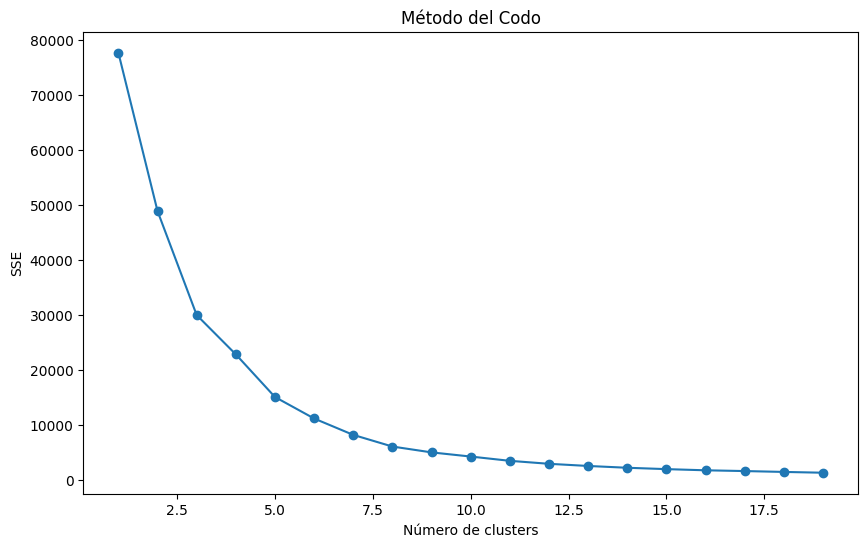

El codo está en k = 5


In [16]:
sse = [] # Aquí guardamos el puntaje de la función objetivo

for k in range(1, 20):
    print(k)
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=1)
    kmeans.fit(df_monopoly_pca)
    sse.append(kmeans.inertia_)

# Graficar el método del codo para ver la elección de k
plt.figure(figsize=(10, 6))
plt.plot(range(1, 20), sse, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("SSE")
plt.title("Método del Codo")
plt.show()

# Now use KneeLocator
kl = KneeLocator(range(1, 20), sse, curve="convex", direction="decreasing")
print("El codo está en k =", kl.elbow)

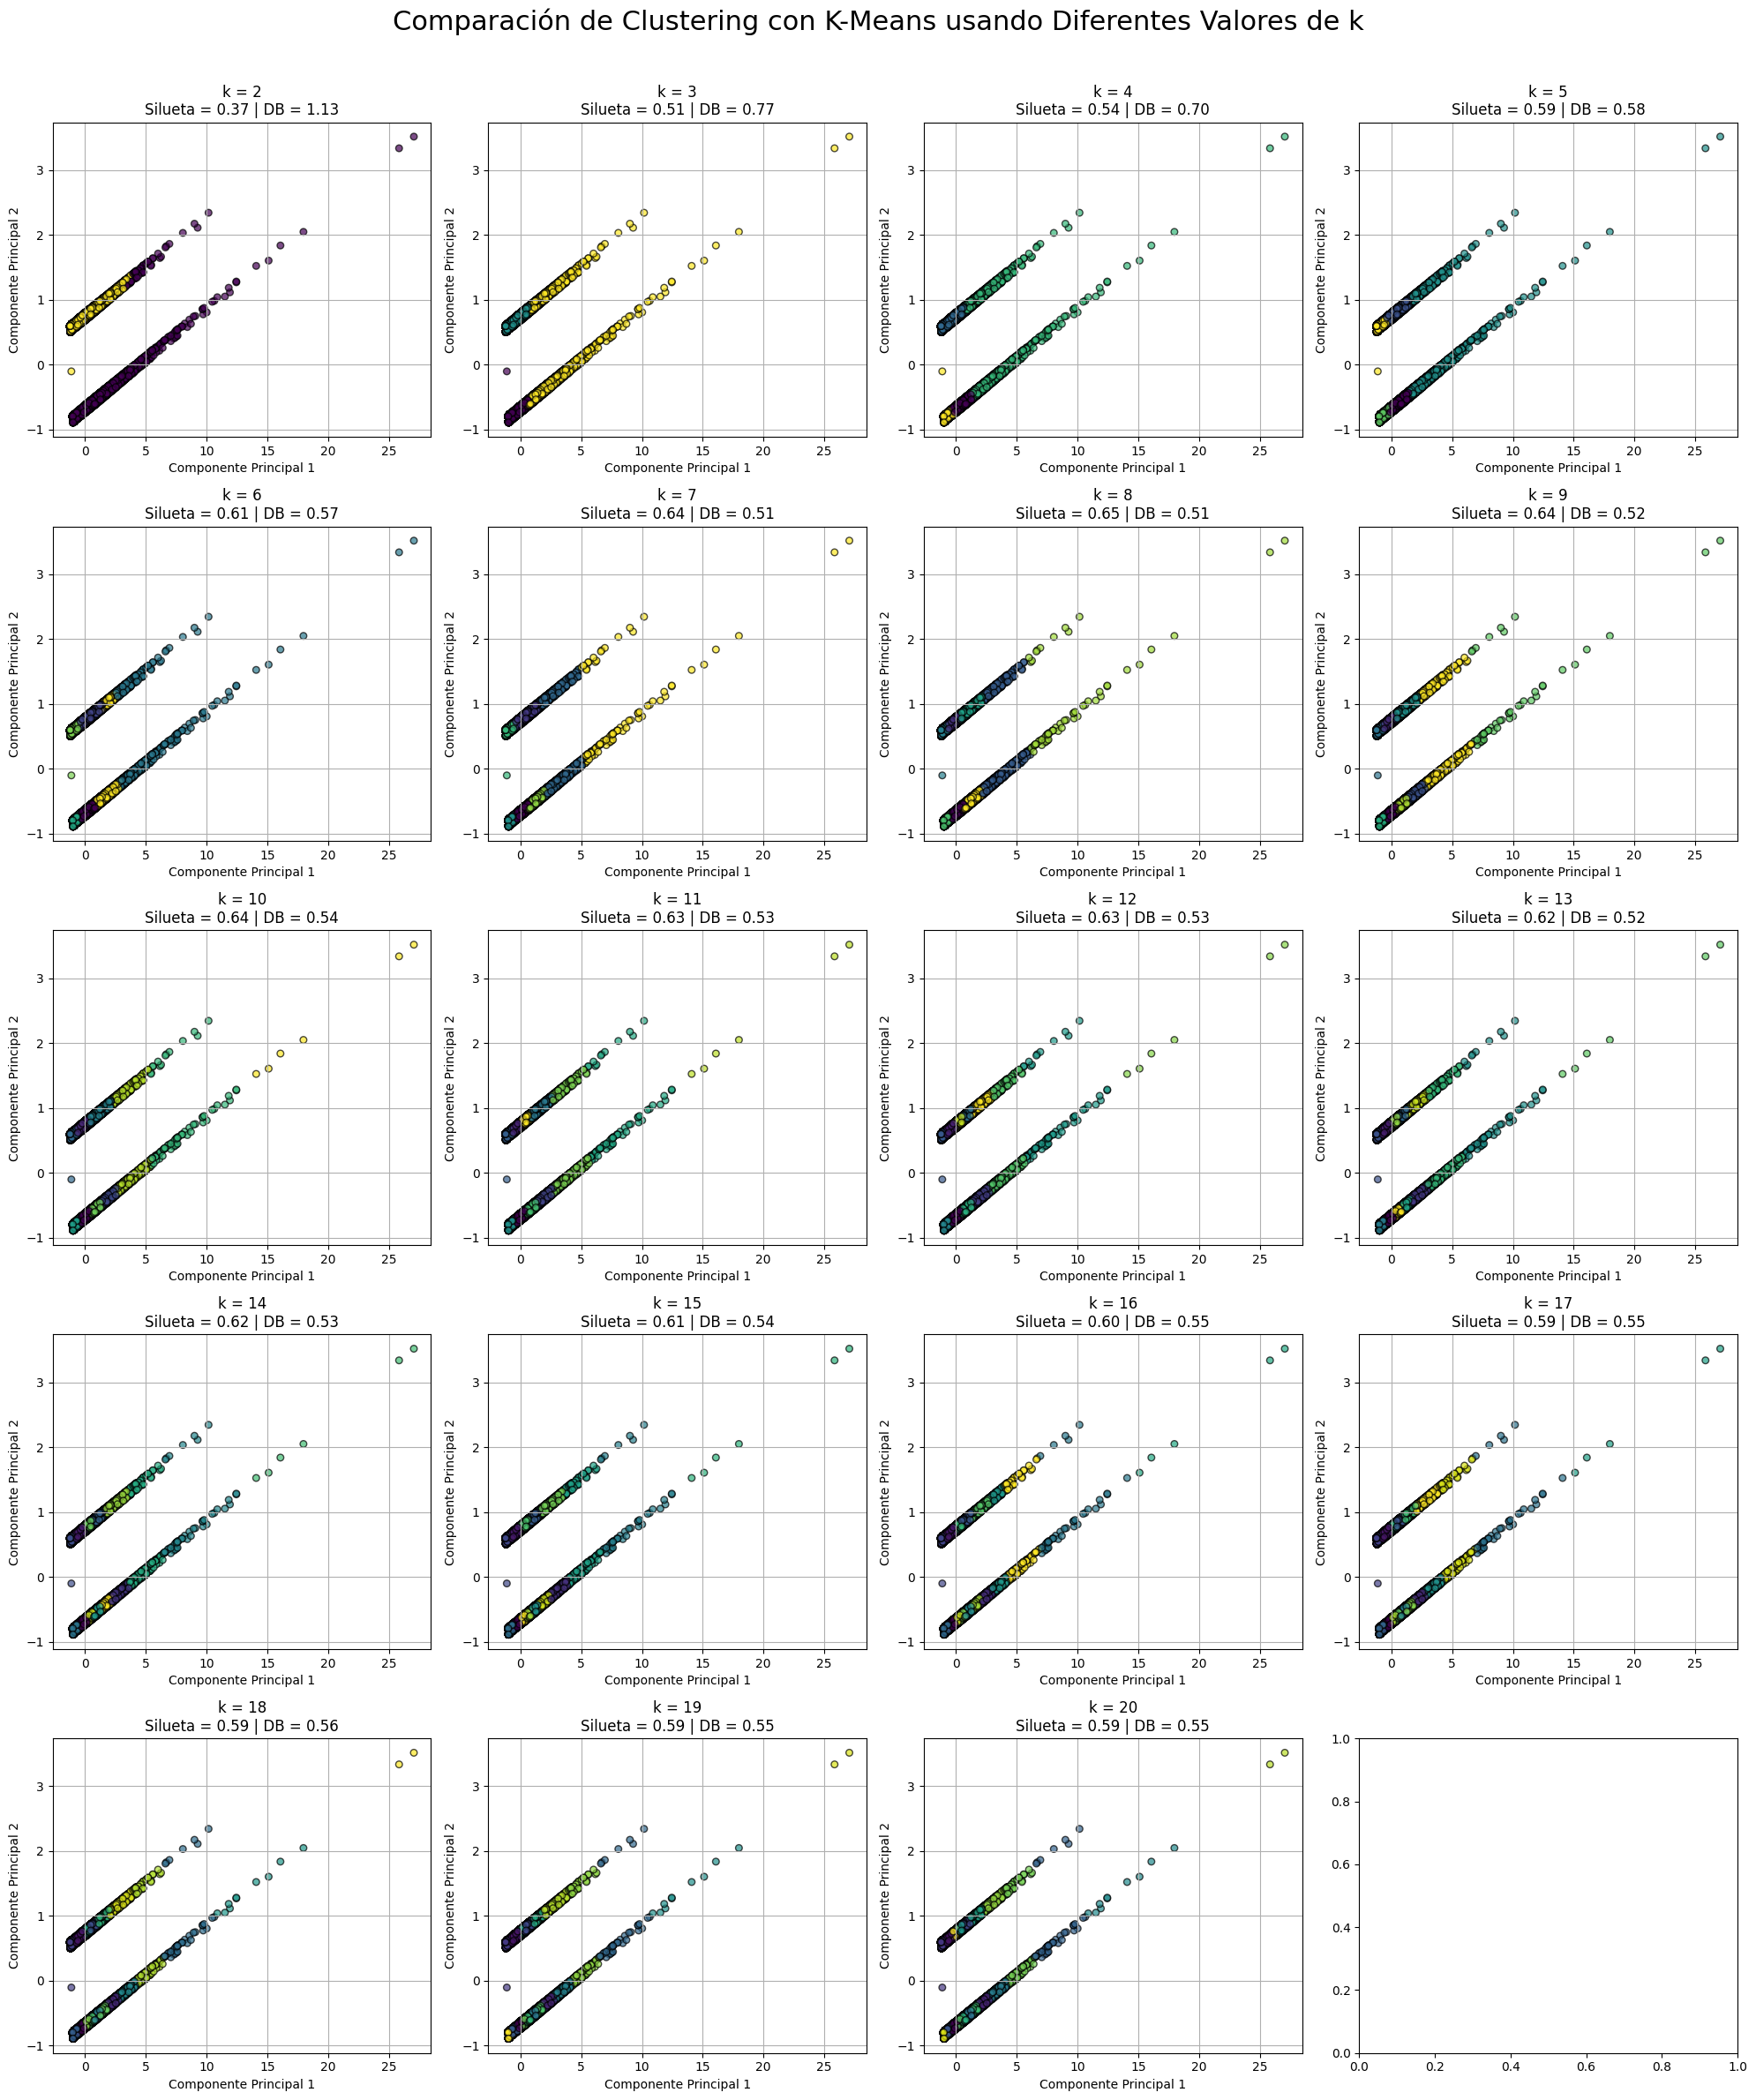

In [184]:
# Supongamos que `df_monopoly` es tu DataFrame ya procesado
df_monopoly_array = df_monopoly_pca

# Configuración de las métricas
silhouette_scores = []
davies_bouldin_scores = []
ks = range(2, 21)

# Evaluar para k en el rango de 2 a 20
for k in ks:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=1)
    labels = kmeans.fit_predict(df_monopoly_array)
    
    # Métricas
    silhouette_scores.append(silhouette_score(df_monopoly_array, labels))
    davies_bouldin_scores.append(davies_bouldin_score(df_monopoly_array, labels))

# Crear los subplots
fig, ax = plt.subplots(5, 4, figsize=(20, 25))
fig.suptitle('Comparación de Clustering con K-Means usando Diferentes Valores de k', fontsize=22)

# Rellenar los subplots
for idx, k in enumerate(ks):
    i, j = divmod(idx, 4)
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(df_monopoly_array)
    
    ax[i, j].scatter(df_monopoly_array[:, 0], df_monopoly_array[:, 1], c=labels, cmap='viridis', s=30, alpha=0.7, edgecolors='k')
    ax[i, j].set_title(f'k = {k}\nSilueta = {silhouette_scores[idx]:.2f} | DB = {davies_bouldin_scores[idx]:.2f}', fontsize=12)
    ax[i, j].set_xlabel('Componente Principal 1')
    ax[i, j].set_ylabel('Componente Principal 2')
    ax[i, j].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


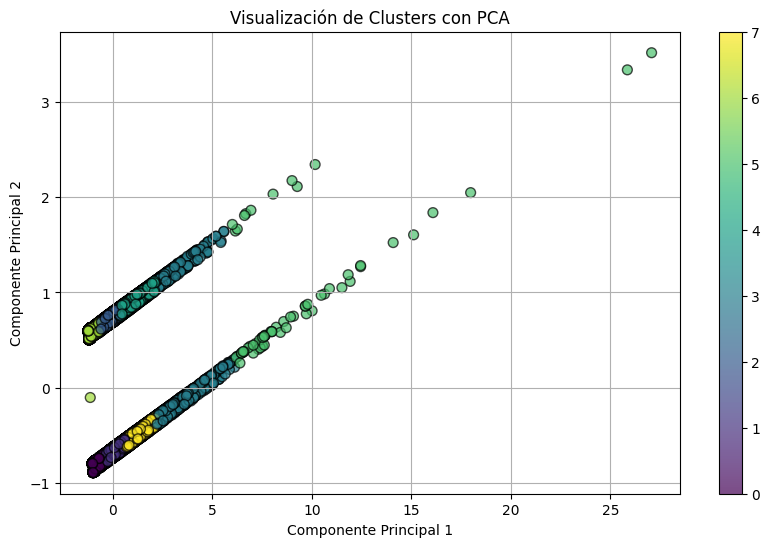

In [17]:
df_monopoly_array = df_monopoly_pca


# Ajustar K-means al DataFrame reducido
k_optimal = 8  # Valor óptimo determinado previamente
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=1)
kmeans.fit(df_monopoly_pca)
labels = kmeans.labels_

# Visualizar todos los datos en un gráfico, coloreados por cluster
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_monopoly_pca[:, 0], df_monopoly_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7, edgecolors='k')
plt.colorbar(scatter)
plt.title("Visualización de Clusters con PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.show()


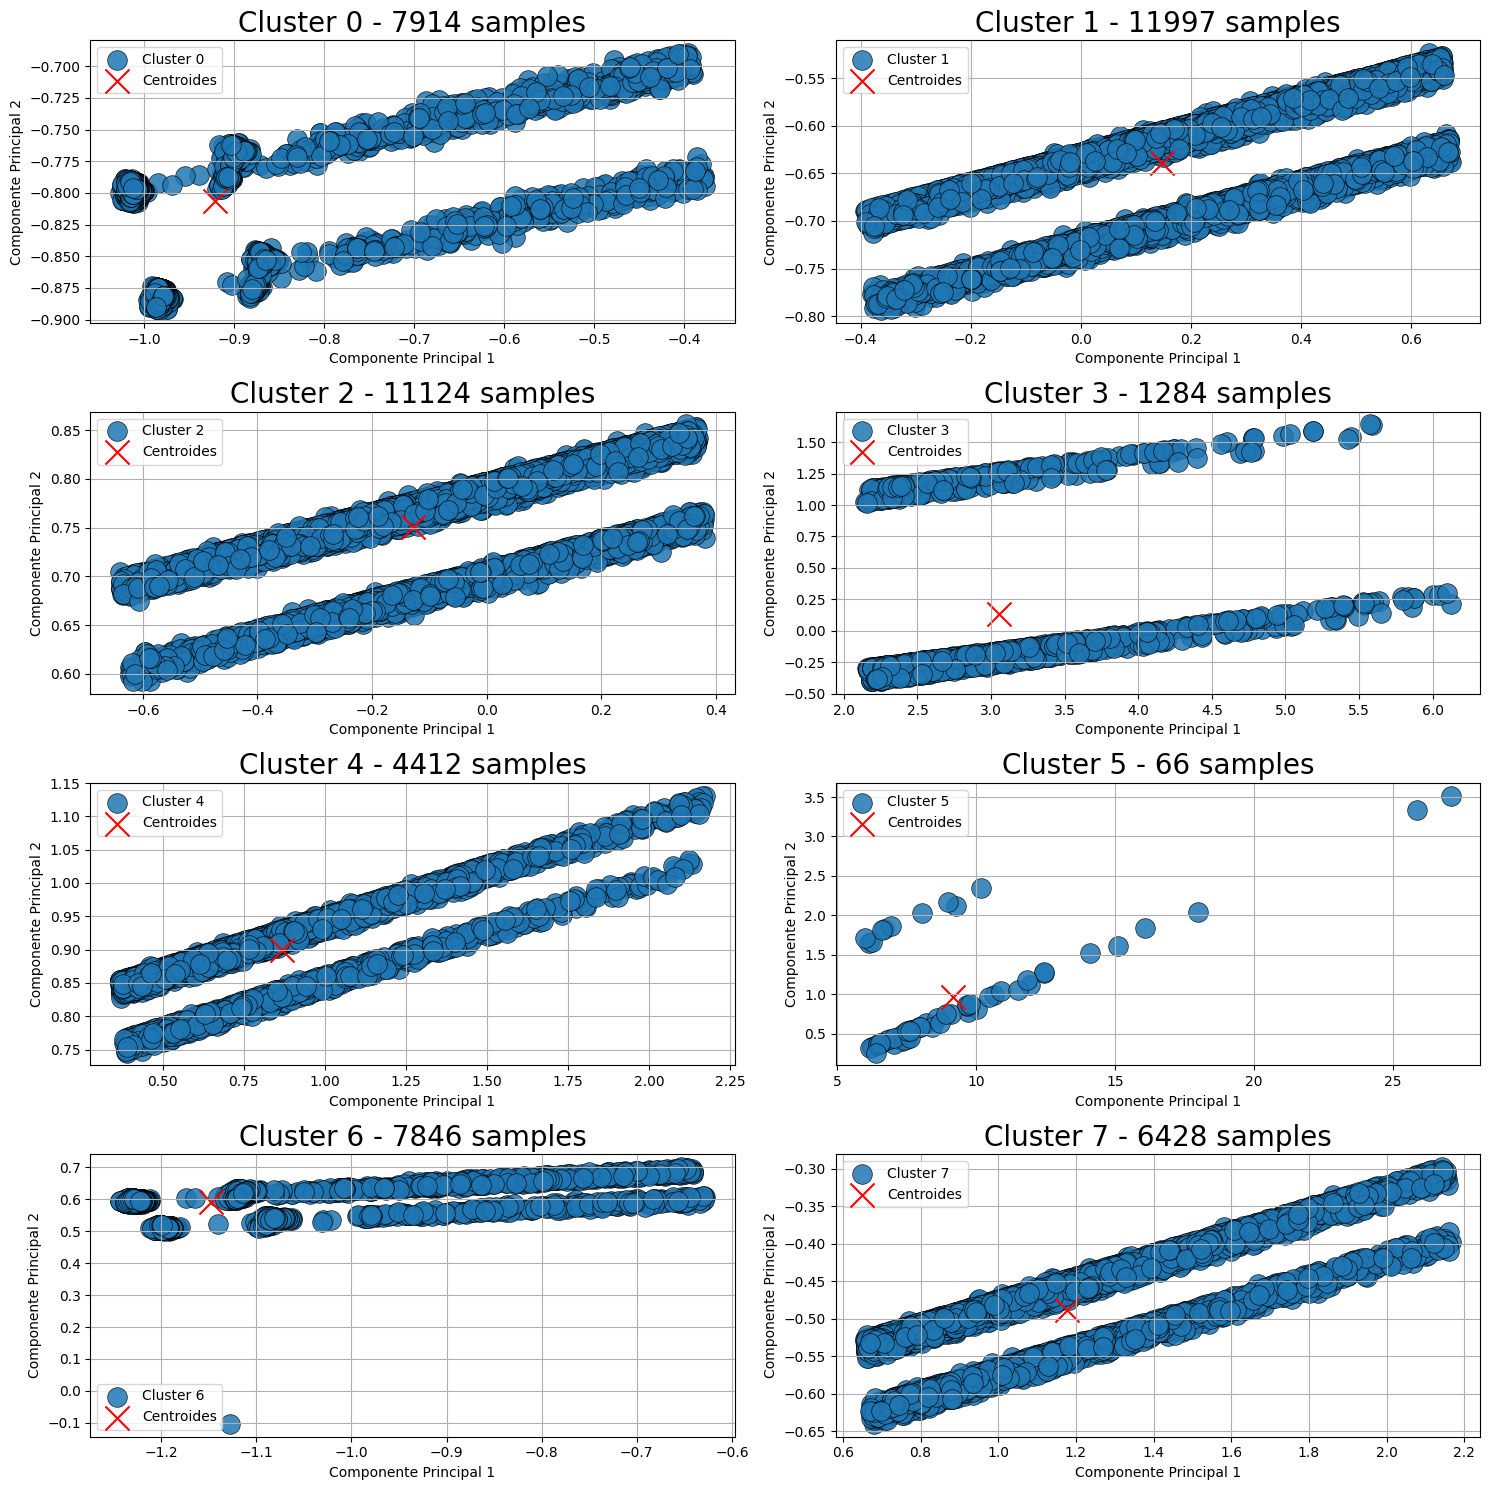

In [18]:
df_monopoly_array = df_monopoly.to_numpy()

# Aplicar PCA para reducir la dimensionalidad a 2 componentes principales para visualización
pca = PCA(n_components=2)
df_monopoly_pca = pca.fit_transform(df_monopoly_array)

# Número óptimo de clusters determinado previamente (por ejemplo, k_optimal = 4)
k_optimal = 8
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=1)
kmeans.fit(df_monopoly_pca)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Crear subplots para cada cluster
fig, ax = plt.subplots(4, 2, figsize=(15, 15))  # 2x2 subplots

unique_labels = np.unique(labels)
for idx, i in enumerate(unique_labels):
    index = np.nonzero(labels == i)[0]  # Índices correspondientes a la i-ésima etiqueta
    num = len(index)  # Número de muestras en cada cluster
    
    if num > 0:
        row, col = divmod(idx, 2)
        ax[row, col].scatter(df_monopoly_pca[index, 0], df_monopoly_pca[index, 1], s=200, 
                             linewidth=0.5, edgecolors="black", alpha=0.85, label=f'Cluster {i}')
        ax[row, col].scatter(centroids[i, 0], centroids[i, 1], s=300, c='red', marker='x', label='Centroides')
        ax[row, col].set_title(f"Cluster {i} - {num} samples", fontsize=20)
        ax[row, col].legend()
        ax[row, col].set_xlabel("Componente Principal 1")
        ax[row, col].set_ylabel("Componente Principal 2")
        ax[row, col].grid(True)

plt.tight_layout()
plt.show()


In [19]:
# Convertir los centroides de vuelta al espacio original (si se aplica PCA)
centroids_original_space = pca.inverse_transform(centroids)

# Crear un DataFrame para mostrar las características de los centroides
centroids_df = pd.DataFrame(centroids_original_space, columns=df_monopoly.columns)
print(centroids_df)


     Region     Renta      Edad    Hombre     Mujer  Adicional   Consumo  \
0  0.802859 -1.021465  0.295894  0.999404  0.000554   0.297553  0.000215   
1  0.814048  0.048133  0.318976  0.996821  0.003160   0.313999  0.001030   
2  0.825269 -0.011670  0.306450 -0.000170  1.000151   0.189741  0.000784   
3  0.847518  2.998536  0.380178  0.770578  0.229468   0.332261  0.003234   
4  0.835616  0.983834  0.327997  0.003087  0.996915   0.205748  0.001543   
5  0.910519  9.116391  0.513154  0.840109  0.160072   0.436757  0.007912   
6  0.814585 -1.031892  0.284444  0.003223  0.996735   0.174169  0.000007   
7  0.824718  1.075736  0.341229  1.001181 -0.001177   0.330645  0.001814   

    Cuentas  Hipotecario  Monoproducto        TC  Dualidad  
0  0.069542     0.036003      0.064042  0.058668  0.263552  
1  0.101414     0.147080      0.058256  0.072685  0.379240  
2  0.103655     0.131324      0.068645  0.060114  0.388820  
3  0.190216     0.451381      0.044505  0.108758  0.701885  
4  0.13329

In [20]:
# Desnormalizar y desestandarizar los centroides 
centroids_df = pd.DataFrame(centroids_original_space, columns=df_monopoly.columns) 
centroids_df[columns_to_standardize] = standard_scaler.inverse_transform(centroids_df[columns_to_standardize]) 
centroids_df[columns_to_normalize]
centroids_df[columns_to_normalize] = minmax_scaler.inverse_transform(centroids_df[columns_to_normalize]) 
print(centroids_df)

      Region         Renta       Edad    Hombre     Mujer  Adicional  \
0  10.634303  2.335553e+04  37.109904  0.999404  0.000554   0.297553   
1  10.768581  5.119738e+05  39.302727  0.996821  0.003160   0.313999   
2  10.903226  4.846544e+05  38.112753 -0.000170  1.000151   0.189741   
3  11.170213  1.859790e+06  45.116906  0.770578  0.229468   0.332261   
4  11.027395  9.394250e+05  40.159733  0.003087  0.996915   0.205748   
5  11.926233  4.654575e+06  57.749592  0.840109  0.160072   0.436757   
6  10.775015  1.859187e+04  36.022151  0.003223  0.996735   0.174169   
7  10.896611  9.814077e+05  41.416777  1.001181 -0.001177   0.330645   

    Consumo   Cuentas  Hipotecario  Monoproducto        TC  Dualidad  
0  0.000215  1.278166     0.036003      0.064042  1.645350  0.263552  
1  0.001030  1.405657     0.147080      0.058256  1.799531  0.379240  
2  0.000784  1.414620     0.131324      0.068645  1.661255  0.388820  
3  0.003234  1.760865     0.451381      0.044505  2.196337  0.70188

# Clusters Jerarquicos

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.cluster.hierarchy as shc

In [ ]:
dend = shc.dendrogram(shc.linkage(df_monopoly_pca, method='ward'))

# DBSCAN